# Choice Model

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

/Users/aarohi_verma/Downloads/final_project/ICCS2026_Final_Project


### Objective

This notebook fits a hyperbolic discounting choice model to participant decisions. Model parameters are estimated by maximizing the likelihood of the observed choices. The fitted model is first demonstrated on a single participant and then applied to the complete dataset.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.config import DATA_DIR
from src.data_loader import load_all_participants
from src.preprocessing import get_split
from src.choice_model import fit_choice_model, predict_choices

### 1. Load Preprocessed Data

The participant data are loaded and the training trials are extracted. These data will be used to estimate the parameters of the choice model.

In [3]:
participants = load_all_participants(DATA_DIR)

train = get_split(
    participants,
    "train"
)

### 2. Inspect a Sample Participant

To show the modelling process, we first select one participant and inspect the available training trials.

In [4]:
participant_id = list(train.keys())[0]
participant = train[participant_id]
participant.head()

,immOutcome,delOutcome,delay,choice,p_imm,condition,RT
0,1.79,5.0,180.0,1.0,0.5,1.0,1721.1
1,9.99,10.0,30.0,1.0,0.5,1.0,2190.2
2,7.33,10.0,365.0,1.0,0.5,1.0,1590.0
3,0.46,50.0,180.0,2.0,0.5,1.0,1804.1
4,0.91,50.0,90.0,2.0,0.5,1.0,1722.5


### 3. Fit the Choice Model

The model parameters are estimated for one participant using maximum likelihood estimation.

In [5]:
result = fit_choice_model(participant)

In [23]:
k, beta = result.x

print(f"Estimated discount rate (k): {k:.4f}")
print(f"Estimated choice sensitivity (β): {beta:.4f}")

Estimated discount rate (k): 0.0156
Estimated choice sensitivity (β): 0.2778


In [8]:
predictions = predict_choices(
    participant,
    k=result.x[0],
    beta=result.x[1]
)

### 4. Predict Choice Probabilities

Using the estimated parameters, the model predicts the probability of choosing the delayed option for each trial.

In [9]:
predictions.head()

,immOutcome,delOutcome,delay,choice,p_imm,condition,RT,SV_immediate,SV_delayed,value_difference,P_delayed
0,1.79,5.0,180.0,1.0,0.5,1.0,1721.1,1.79,1.313854,-0.476146,0.466979
1,9.99,10.0,30.0,1.0,0.5,1.0,2190.2,9.99,6.813848,-3.176152,0.292691
2,7.33,10.0,365.0,1.0,0.5,1.0,1590.0,7.33,1.494963,-5.835037,0.165067
3,0.46,50.0,180.0,2.0,0.5,1.0,1804.1,0.46,13.138542,12.678542,0.971312
4,0.91,50.0,90.0,2.0,0.5,1.0,1722.5,0.91,20.809068,19.899068,0.996042


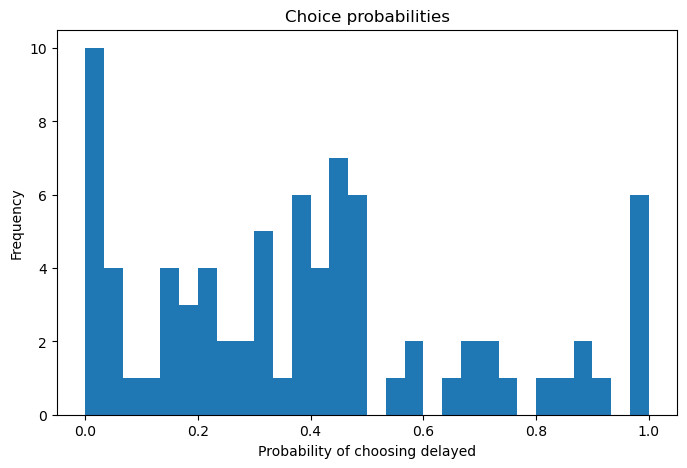

In [10]:
plt.figure(figsize=(8,5))
plt.hist(
    predictions["P_delayed"],
    bins=30
)
plt.xlabel("Probability of choosing delayed")
plt.ylabel("Frequency")
plt.title("Choice probabilities")
plt.show()

The estimated probabilities span the full range between 0 and 1, indicating that the fitted model captures varying levels of decision confidence across trials.

### 5. Fit the Model to All Participants

In [11]:
from src.inference import fit_all_participants

In [12]:
results = fit_all_participants(participants)

In [14]:
results.head()

,participant,k,beta,negative_log_likelihood,success
0,Sample1_07mpzgefw,0.015587,0.277804,36.724521,True
1,Sample1_0ow9y3ng4,0.010188,16.971269,10.753989,True
2,Sample1_19j097r6c,0.001340,4.560746,13.205702,True
3,Sample1_1pwx30q0h,0.009929,20.000000,12.782909,True
4,Sample1_2k3imu1lz,0.008564,1.605976,17.812107,True


In [24]:
print(results["success"].value_counts())

print(
    f"Successful fits: {results['success'].sum()} / {len(results)}"
)

success
True     98
False     1
Name: count, dtype: int64
Successful fits: 98 / 99


In [16]:
results.describe()

,k,beta,negative_log_likelihood
count,99.000000,99.000000,99.000000
mean,0.047174,4.217845,31.784491
std,0.141370,6.694497,16.917366
min,0.000010,0.018430,0.000245
25%,0.001129,0.382831,18.981116
50%,0.009143,1.022167,32.759188
75%,0.010423,3.323052,42.130496
max,0.992119,20.000000,99.221006


### 6. Save Estimated Parameters

The estimated model parameters for all participants are saved for later use in the reaction time model.

In [17]:
results.to_csv("../results/choice_model_parameters.csv", index=False)

### 7. Distribution of Estimated Discount Rates

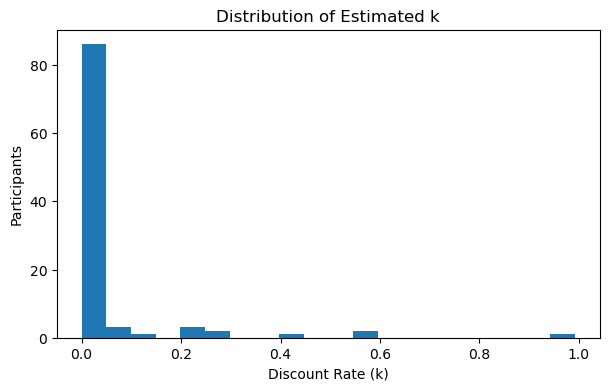

In [18]:
plt.figure(figsize=(7,4))
plt.hist(results["k"], bins=20)
plt.xlabel("Discount Rate (k)")
plt.ylabel("Participants")
plt.title("Distribution of Estimated k")
plt.show()

Most participants exhibit relatively small discount rates, indicating a tendency to retain value for delayed rewards.

### 8. Distribution of Estimated Choice Sensitivity (β)

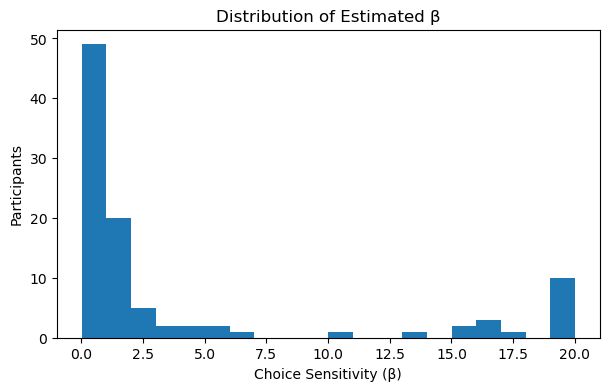

In [19]:
plt.figure(figsize=(7,4))
plt.hist(results["beta"], bins=20)
plt.xlabel("Choice Sensitivity (β)")
plt.ylabel("Participants")
plt.title("Distribution of Estimated β")
plt.show()

The β parameter reflects how consistently participants choose the option with the higher subjective value. Larger values indicate more deterministic choices.

### 9. Unsuccessful Model Fits

In [20]:
results[results["success"] == False]

,participant,k,beta,negative_log_likelihood,success
97,Sample2_ygx60l0no,0.001117,0.700055,34.62018,False
